In [1]:
import warnings
warnings.filterwarnings('ignore')

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width="25%" height="25%" />

# Pandas - Topic 06 - Missing data

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* **Understand** what missing data is, and **exercises** using Pandas methods for dealing with it

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Package for Learning

In [2]:
import numpy as np
import pandas as pd

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Missing data

In this notebook we will cover

* how to check missing data levels with `.isnull()`
* how to drop missing data with `.dropna()`
* how to fill missing data with `.fillna()`

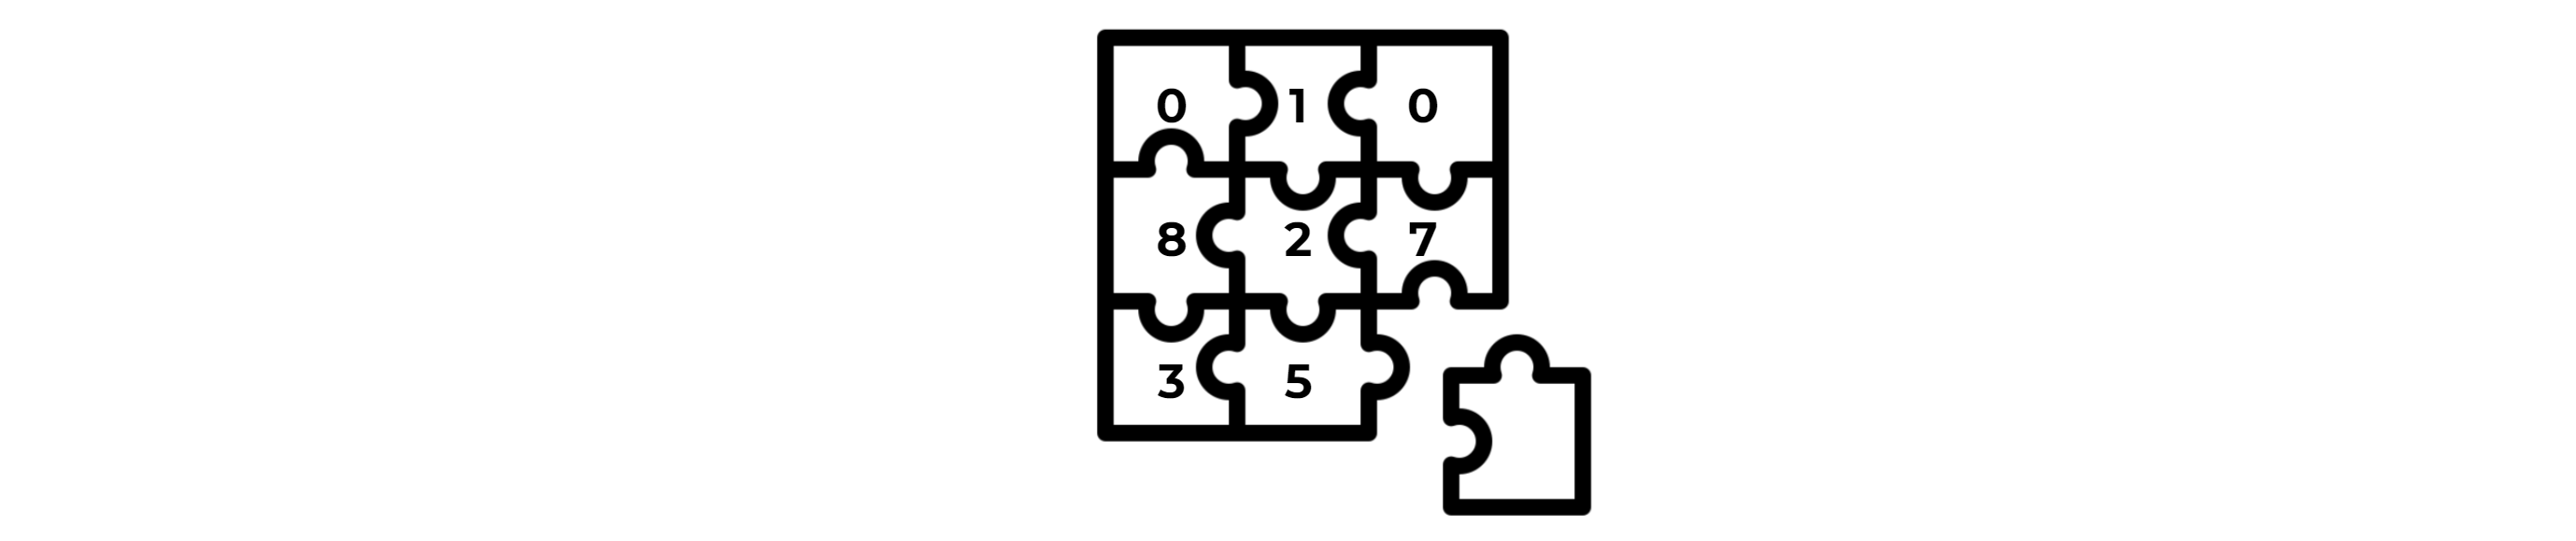

The central message for this notebook is that you have **multiple ways** to fill in the missing data of your datasets.
* We will study in the upcoming lessons a library called `feature-engine`, which has a broad set of functions to handle missing data
  * It is a matter of **experience and business acumen** to understand the most suitable approach to apply to your variable that has missing data

---

Before defining missing data, let's use a NumPy function called [np.random.choice()](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) for this particular unit; it will generate a random sample of data. The arguments are: 
  * the data itself
  * `size`, which is the output's shape

Imagine if your data is a list: `[1, 2, 3]`; and you want to create an array with **7 elements** made with random elements from that list
  * Since it is a random generation, we set the seed first

In [3]:
np.random.seed(seed=2)
np.random.choice([1,2,3], size=7)

array([1, 2, 1, 3, 3, 1, 3])

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png">

 It will be very common in the workplace to get datasets with **missing data**


It occurs when **no data point** is stored for the variable at a given observation
* Let's consider the DataFrame example below. We used a python dictionary to create 3 columns (A,B,C), and some elements are missing, created using NumPy: `np.nan` and `np.random.choice()`

In [4]:
np.random.seed(seed=1)
df = pd.DataFrame(data={'A':np.random.choice([1,2,3,np.nan], size=3),
                        'B':np.random.choice([1,np.nan], size=3),
                        'C':np.random.choice([10,20], size=3)
                        })
df

,A,B,C
0,2.0,1.0,20
1,NaN,NaN,20
2,1.0,NaN,20


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### .isnull()

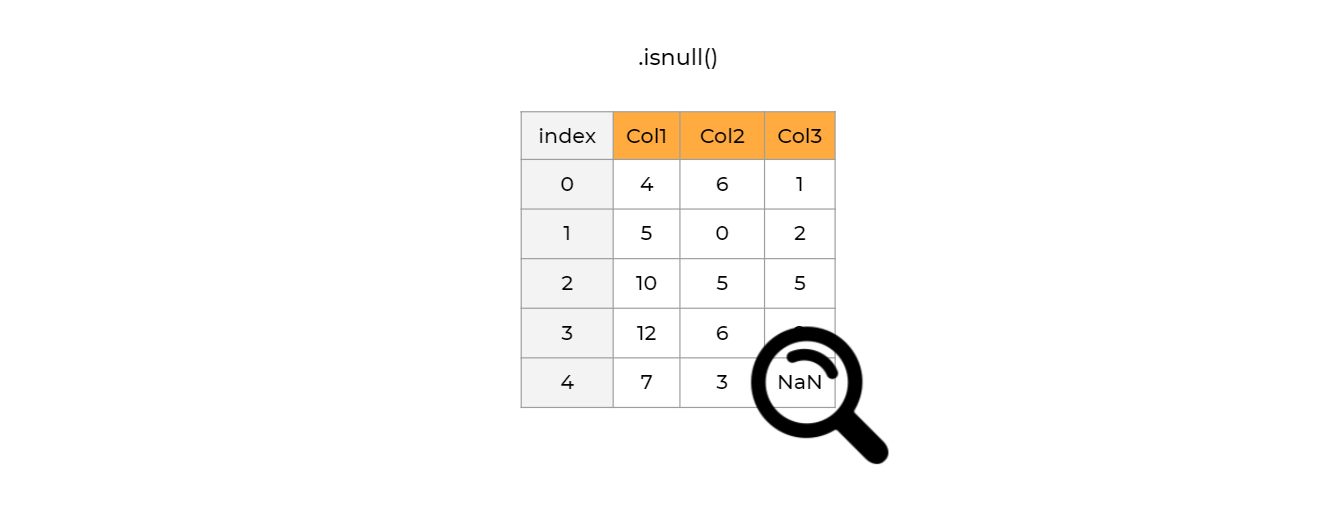

You can check for missing data levels with the method `.isnull().` The result is a boolean array.
  * The function documentation is found [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)

In [5]:
df.isnull()

,A,B,C
0,False,False,False
1,True,True,False
2,False,True,False


Then, add the `.sum()` method to assess how many missing data rows you have per column.
  * This is the **simplest way to check for missing data levels** in your tabular data
  * The function documentation is found [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)

In [6]:
df.isnull().sum()

A    1
B    2
C    0
dtype: int64

Once you are aware of its levels, you can decide which actions to take to handle the missing data


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: Consider the dataset below. It’s UK MacroData, but has records with empty values. Bank rate includes values at periods when it was changed only (for example Bank Rate was changed to 6% at year 2000 quarter 2 and then was constant till it was changed to 5.75 at year 2001 quarter 1). And, we couldn’t get GDP and CPI data for the whole 2020 year.

In [7]:
df_practice = pd.read_csv("UK_MacroDataMissingValues.csv")
df_practice

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242.0,1.1,5.875,69114.0
1,2000 Q2,404196.0,1.0,6.000,73074.0
2,2000 Q3,406795.0,1.2,6.000,68011.0
3,2000 Q4,409411.0,1.4,NaN,70115.0
4,2001 Q1,413054.0,1.3,NaN,70186.0
...,...,...,...,...,...
91,2022 Q4,568034.0,9.4,3.250,106689.0
92,2023 Q1,569336.0,9.0,4.125,109290.0
93,2023 Q2,569364.0,7.7,4.750,108245.0
94,2023 Q3,NaN,6.3,5.250,106496.0


In [8]:
# write your code here
df_practice.isnull().sum()

Date                                            0
GDP (£ m)                                       4
CPI                                             4
Bank Rate                                      57
Gross Fixed Capital Formation (Investments)     1
dtype: int64

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### .dropna()

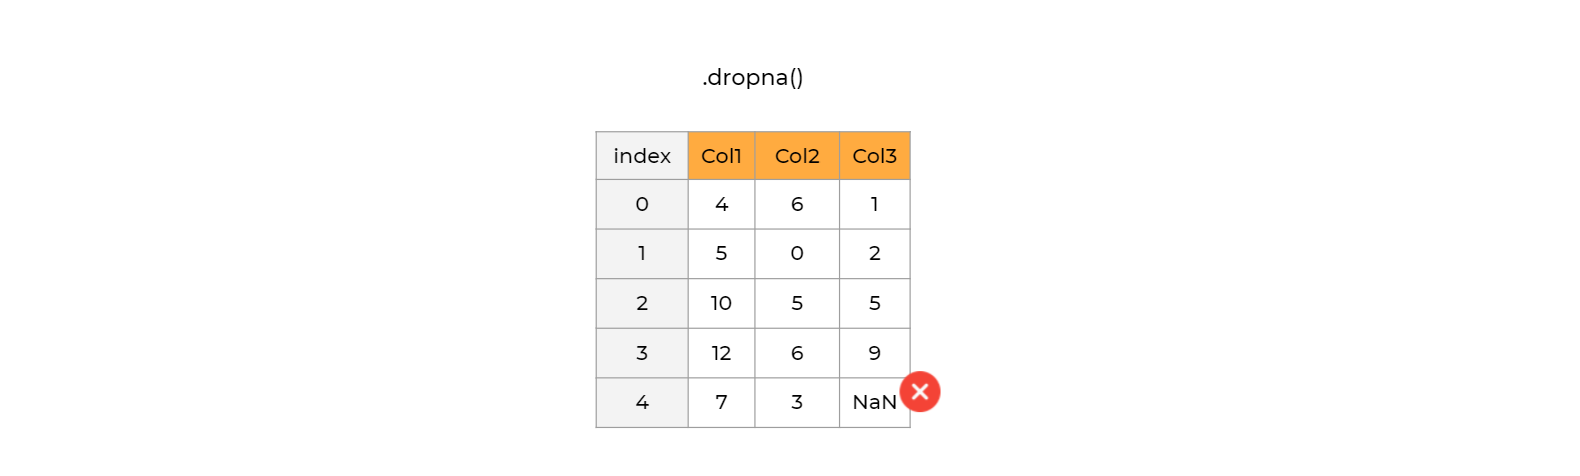

Let's recap the content of df

In [9]:
df

,A,B,C
0,2.0,1.0,20
1,NaN,NaN,20
2,1.0,NaN,20


One possibility is to drop missing data using Pandas' capabilities. 


For that use `.dropna()`. In this case, it drops all rows that have missing data
  * When you don't set the axis, the default value is `axis=0`, meaning you are dropping rows
  * **REMEMBER** that you didn't overwrite the DataFrame since `inplace` is not set to `True`
  * The function documentation is found [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)

In [10]:
df.dropna()

,A,B,C
0,2.0,1.0,20


You can also drop all columns that have missing data

In [11]:
df.dropna(axis=1) 

,C
0,20
1,20
2,20


---

You can set a threshold to drop columns or rows, with the `thresh` parameter
  * The example below sets a threshold of 2 to drop a given row that has missing data
  * You will notice that the row with 1 missing piece of data was not dropped

In [12]:
df.dropna(thresh=2)

,A,B,C
0,2.0,1.0,20
2,1.0,NaN,20


---

You can drop missing data for a particular set of variables
* In the workplace, for example, you may be interested in dropping data from a given set of variables, and for another set of variables, you may be interested in applying some other method

You must use the parameter ``subset`` and parse a list of the variables you want to drop.

In [13]:
df.dropna(subset=['A'])

,A,B,C
0,2.0,1.0,20
2,1.0,NaN,20


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: for the `df_practice` dataset, drop all missing rows from `Gross Fixed Capital Formation (Investments)`
* Note: you do not have to overwrite the DataFrame


Your output should look like

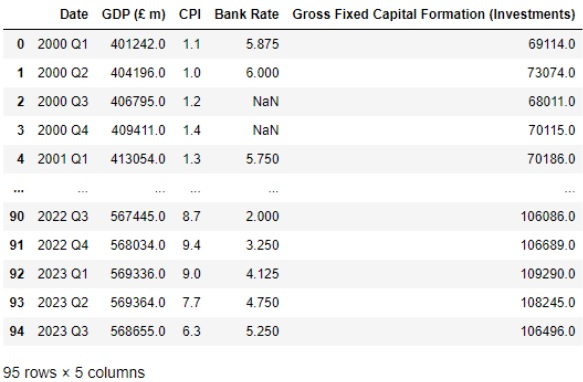

In [14]:
# write your code here
df_practice.dropna(subset=['Gross Fixed Capital Formation (Investments)'])

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242.0,1.1,5.875,69114.0
1,2000 Q2,404196.0,1.0,6.000,73074.0
2,2000 Q3,406795.0,1.2,6.000,68011.0
3,2000 Q4,409411.0,1.4,NaN,70115.0
4,2001 Q1,413054.0,1.3,NaN,70186.0
...,...,...,...,...,...
90,2022 Q3,567445.0,8.7,2.000,106086.0
91,2022 Q4,568034.0,9.4,3.250,106689.0
92,2023 Q1,569336.0,9.0,4.125,109290.0
93,2023 Q2,569364.0,7.7,4.750,108245.0


---

 <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### .fillna()

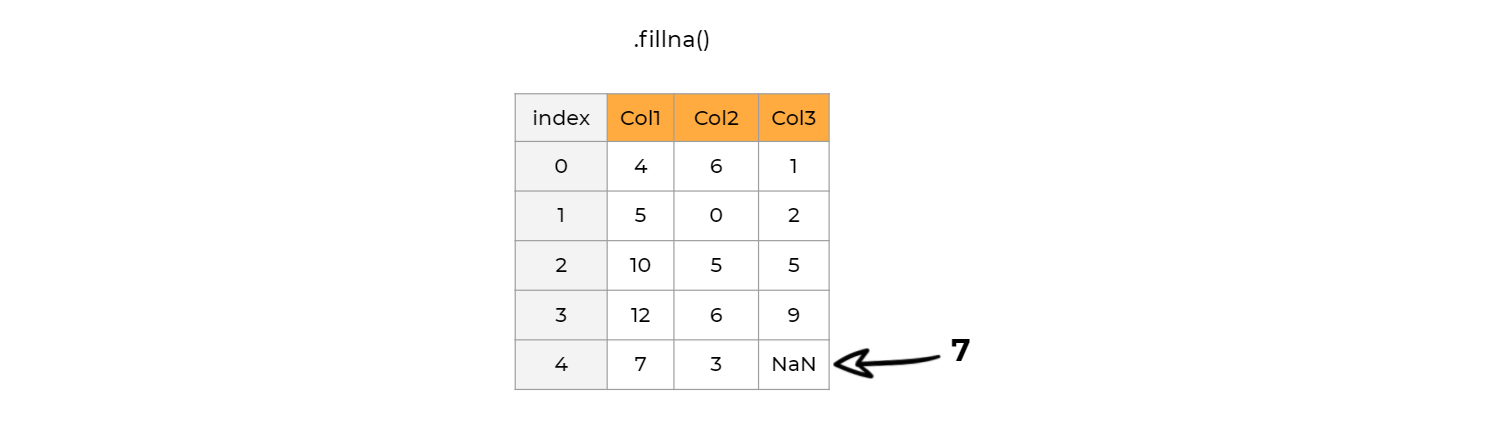

You can also fill in values using `.fillna()`. The argument is "value", which can be constant or calculated. The function documentation is found [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html)

First a recap on what the `df` looks like

In [15]:
df

,A,B,C
0,2.0,1.0,20
1,NaN,NaN,20
2,1.0,NaN,20


Let's fill with a string - '`Constant_Value`' and replace all missing data in that DataFrame

In [16]:
df.fillna(value='Constant_Value')

,A,B,C
0,2.0,1.0,20
1,Constant_Value,Constant_Value,20
2,1.0,Constant_Value,20


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Please note that in the example above, when you fill the missing data with a string in a numerical variable, that given variable becomes categorical (object). We can check that with `.info() `after we `.fillna()`

In [17]:
df.fillna(value='Constant_Value').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   A       3 non-null      object
 1   B       3 non-null      object
 2   C       3 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


---

You can fill in the missing data with a numerical value. As in the example below, using -4

In [18]:
df.fillna(value=-4)

,A,B,C
0,2.0,1.0,20
1,-4.0,-4.0,20
2,1.0,-4.0,20


---

You can calculate the value to be filled in. The example below **calculates the mean for column A** and inserts this value where it is missing for that column. 
  * Note `inplace=True`

In [19]:
df['A'].fillna(value=df['A'].mean(),inplace=True)
df

,A,B,C
0,2.0,1.0,20
1,1.5,NaN,20
2,1.0,NaN,20


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: consider `df_practice`for 2019-2021 period

In [20]:
df_practice = pd.read_csv("UK_MacroDataMissingValues.csv").iloc[76:88,]
df_practice

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
76,2019 Q1,555141.0,1.8,NaN,102105.0
77,2019 Q2,NaN,2.0,NaN,101275.0
78,2019 Q3,560987.0,1.8,0.750,102100.0
79,2019 Q4,560861.0,1.4,0.750,100943.0
80,2020 Q1,NaN,1.7,0.175,97191.0
81,2020 Q2,434718.0,0.8,0.100,78563.0
82,2020 Q3,507643.0,0.8,NaN,90756.0
83,2020 Q4,514531.0,0.8,NaN,96147.0
84,2021 Q1,509261.0,0.9,NaN,93777.0
85,2021 Q2,546579.0,2.1,0.100,98872.0


Use the mean level to fill in the missing data for '`CPI`' and fill using `558480` for the '`GDP (£ m)`' variable. Do your exercise in 2 lines of code, using `inplace=True` when appropriate. Your third line should be `df_practice`, so you can check a snapshot of your DataFrame and see, particularly on rows with index 80-83, where both variables we filled in


Your output should look like

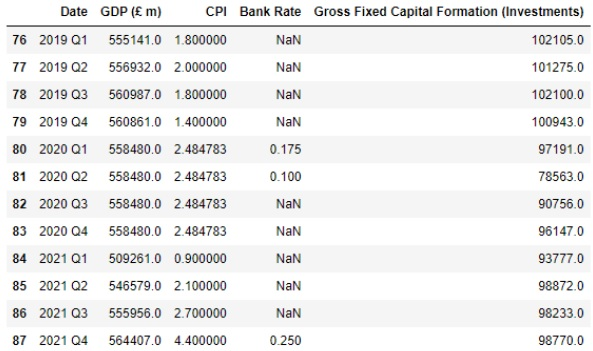

In [21]:
df_practice['CPI'].fillna(value=df_practice['CPI'].mean(),inplace=True)# line 1 - write your code here
df_practice['GDP (£ m)'].fillna(value=558480,inplace=True)# line 2 - write your code here
df_practice

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
76,2019 Q1,555141.0,1.8,NaN,102105.0
77,2019 Q2,558480.0,2.0,NaN,101275.0
78,2019 Q3,560987.0,1.8,0.750,102100.0
79,2019 Q4,560861.0,1.4,0.750,100943.0
80,2020 Q1,558480.0,1.7,0.175,97191.0
81,2020 Q2,434718.0,0.8,0.100,78563.0
82,2020 Q3,507643.0,0.8,NaN,90756.0
83,2020 Q4,514531.0,0.8,NaN,96147.0
84,2021 Q1,509261.0,0.9,NaN,93777.0
85,2021 Q2,546579.0,2.1,0.100,98872.0


---

Consider the whole UK MacroData DataFrame with empty (missing) values

In [22]:
df = pd.read_csv("UK_MacroDataMissingValues.csv")
df

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242.0,1.1,5.875,69114.0
1,2000 Q2,404196.0,1.0,6.000,73074.0
2,2000 Q3,406795.0,1.2,6.000,68011.0
3,2000 Q4,409411.0,1.4,NaN,70115.0
4,2001 Q1,413054.0,1.3,NaN,70186.0
...,...,...,...,...,...
91,2022 Q4,568034.0,9.4,3.250,106689.0
92,2023 Q1,569336.0,9.0,4.125,109290.0
93,2023 Q2,569364.0,7.7,4.750,108245.0
94,2023 Q3,NaN,6.3,5.250,106496.0


* You can consider another argument: `method`. In the `.fillna()` [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html), there are few methods to consider.
* You can select '`ffill`', where you will **propagate the last valid observation forward**

In [23]:
df.fillna(method='ffill')

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242.0,1.1,5.875,69114.0
1,2000 Q2,404196.0,1.0,6.000,73074.0
2,2000 Q3,406795.0,1.2,6.000,68011.0
3,2000 Q4,409411.0,1.4,6.000,70115.0
4,2001 Q1,413054.0,1.3,6.000,70186.0
...,...,...,...,...,...
91,2022 Q4,568034.0,9.4,3.250,106689.0
92,2023 Q1,569336.0,9.0,4.125,109290.0
93,2023 Q2,569364.0,7.7,4.750,108245.0
94,2023 Q3,569364.0,6.3,5.250,106496.0


---

* Or, you can consider '`bfill`', where you **use the next valid observation to fill the gap**
  * You will notice that the last row of Bank Rate and Gross Fixed Capital Formation (Investments) still has a missing value, since it can't find a **next row** to use the method

In [24]:
df.fillna(method='bfill')

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242.0,1.1,5.875,69114.0
1,2000 Q2,404196.0,1.0,6.000,73074.0
2,2000 Q3,406795.0,1.2,6.000,68011.0
3,2000 Q4,409411.0,1.4,3.500,70115.0
4,2001 Q1,413054.0,1.3,3.500,70186.0
...,...,...,...,...,...
91,2022 Q4,568034.0,9.4,3.250,106689.0
92,2023 Q1,569336.0,9.0,4.125,109290.0
93,2023 Q2,569364.0,7.7,4.750,108245.0
94,2023 Q3,566695.0,6.3,5.250,106496.0


It’s another useful method, but not for Bank Rate case. Therefore we need to choose the fillna method carefully.